In [ ]:
Content:
1. XOR 
2. Array
3. GCD
4. Factors
5. Binary Search
6. Arrays
7. Sorting
8. Sliding Window

In [ ]:
# Python list Insertion and Deletion.
# deque takes O(1) from both ends, where as List takes O(N)

from collections import deque
a = deque([1, 2, 3, 4, 5])
a.append(6)
a.pop()
a.appendleft(0) # Append at start
a.popleft() # Pop from start

b = [1,2,3,4,5]
b.append(6)
b.pop()
b.insert(0, 10)
b.pop(0)
b


In [ ]:
Array Solution:
- Two pointer approach
  - starting from [0, N-1] (mostly when array is sorted)
  - starting from [0, 0].  (when array is unsorted) (Sliding window (when all elements are positive)
- use Hash map to add elements Arr[i] or fun(Arr[i])
   - {'number': last_occurance}                                                       
- if sub-array is not sorted, and a sub-array is asked, then think for a pre-fix array.
- pre-fix sum array and hash map.

- If an array of fixed range of numbers is given, [1, 500] we can create an array with these indexes.


In [1]:
Array Ideas:
1. Arrays with numbers
   - Prefix and postfix sum array
   - To optimize like (minimize/ maximize), consider an answer space and apply binary search.

2. Bit wise operation
 A ^ A = 0
 - To check if bit is set: A & (1<<bit_index) > 0
 - To set bit as 1: result |= (1 << i)
 - To set 0 as bit: N = N &~(1<<3)

SyntaxError: invalid syntax (3562511885.py, line 1)

In [ ]:
Properties of XOR
1. A ^ A ^ B = B
2. A ^ B = C, then C ^ A = B


Count Subarrays with given XOR
Input: arr[] = [4, 2, 2, 6, 4], k = 6
Output: 4
Explanation: The subarrays having XOR of their elements as 6 are [4, 2], [4, 2, 2, 6, 4], [2, 2, 6], and [6].
x
Solution 1: TC: N^2

def subarrayXor(arr, k):
    res = 0
    for i in range(len(arr)):
        prefXOR = 0
        for j in range(i, len(arr)):
            prefXOR ^= arr[j]
            if prefXOR == k:
                res += 1

    return res

Solution 2: TC: O(N)
- Intution: if XOR of A[1:3] is K, which is what we want.(above example: [2,2,6]
- then [4] XOR [4,2,2,6] = k,  # [4] is prefixXOR stored in map and [4,2,2,6] is current prefix_XOR 
   then [4, 2,2,6] XOR k = [4] # So, if [4] exist in map, then subarray [2,2,6] is one of our answer.
- All the operation are performed in sub-array, starting from 0 index.

def subarrayXor(arr, k):
    result = 0
    prefXOR = 0   
    prefix_map = {}


    for val in arr:
        prefXOR ^= val
        prefix_map[prefXOR] = prefix_map.get(prefXOR, 0) + 1

        # If there exist a sub-array starting from 0 index, ending at iteratively each element, then just increase answer.
        if prefXOR == k:
            result += 1

        # It check, if the prefix XOR starting from 0 to i, XOR k, existing in map. 
        # if yes, that means, there is another sub-array starting from 0 index, ending at index less than i.
        result += prefix_map.get(prefXOR ^ k, 0)

    return result

In [ ]:
Question 1: Given an unsorted array, maximize |A[i] - A[j]| + (i-j)
Solution 1:
Unique Expressions:
  - X = A[i] + i
  - Y  = A[i] - i

final_answer = max(max(X) - min(X), max(Y) - min(Y))







This equation can be converted to:
1. (A[i] + i) - (A[j] + j)
2. (A[i] - i) - (A[j] - j)

def maxEquationValue(arr):
    if not arr:
        return 0  # Edge case: Empty array

    max1 = max2 = float('-inf')
    min1 = min2 = float('inf')

    for i in range(len(arr)):
        max1 = max(max1, arr[i] + i)
        min1 = min(min1, arr[i] + i)
        max2 = max(max2, arr[i] - i)
        min2 = min(min2, arr[i] - i)

    return max(max1 - min1, max2 - min2)



In [ ]:
| A - B | = max(A - B, B - A)

•	For k absolute values, it directly gives 2^k / 2 unique expressions.


In [ ]:
# Maximize the Absolute Value of Expression |arr1[i] - arr1[j]| + |arr2[i] - arr2[j]| + |i - j|

We have three absolute terms:
	1.	|arr1[i] - arr1[j]| → Affects sign of arr1[i]
	2.	|arr2[i] - arr2[j]| → Affects sign of arr2[i]
	3.	|i - j| → Affects sign of i

Each term can be written as:

+-arr1[i], +-arr2[i], +-i
    

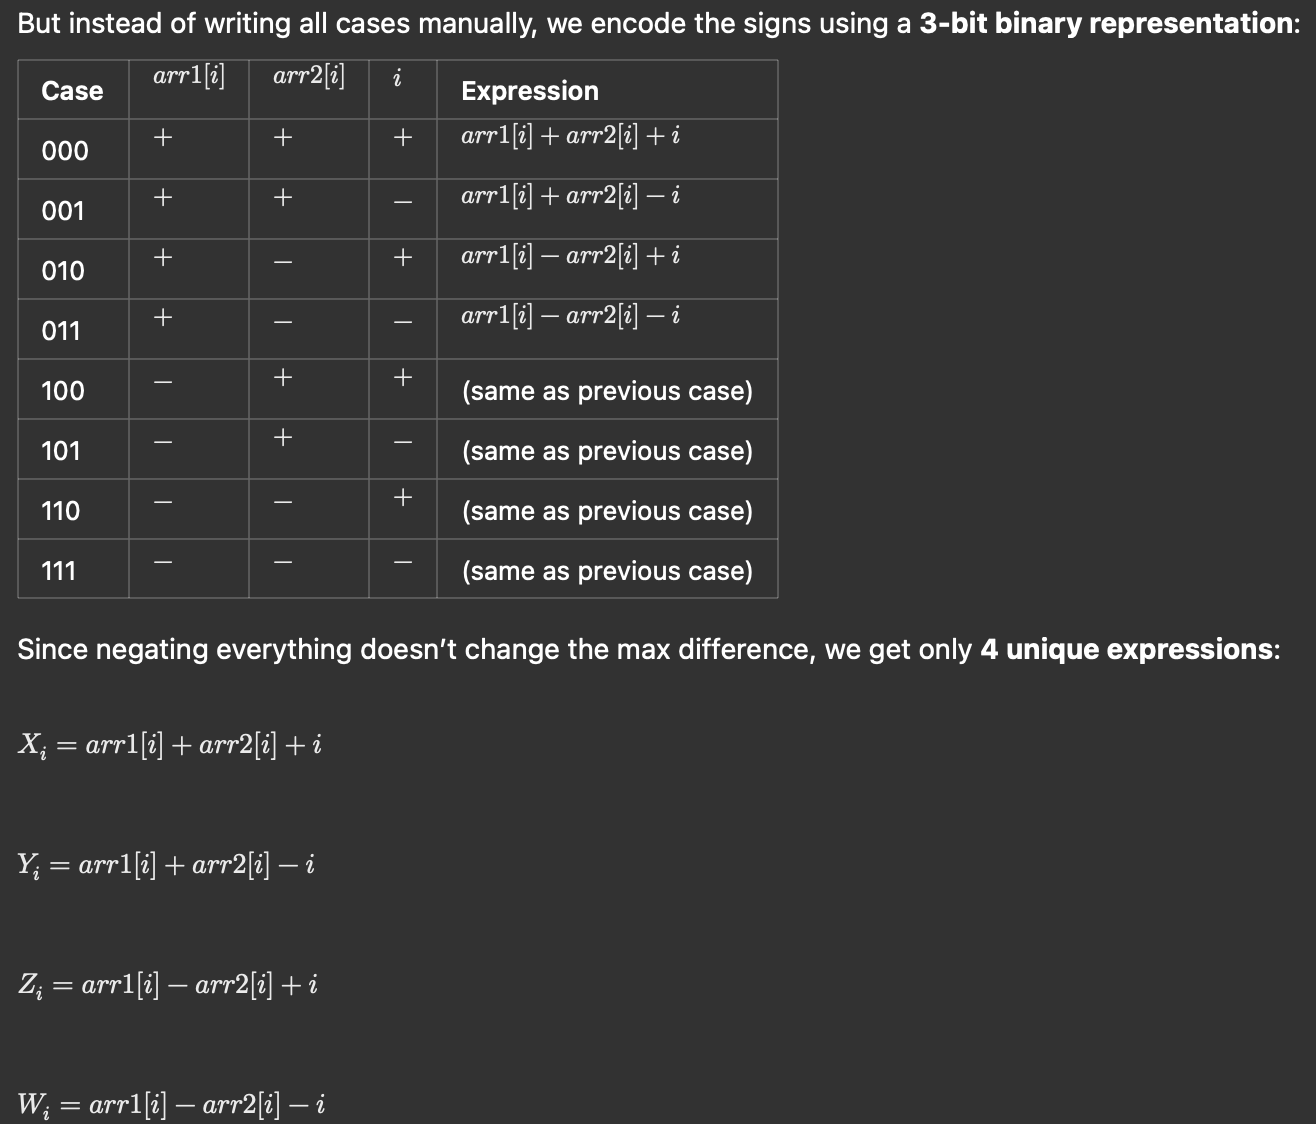
final_answer = max(max(X) - min(X), max(Y) - min(Y), max(Z) - min(Z), max(W) - min(W))

Question 3: |arr1[i] - arr1[j]| + |arr2[i] - arr2[j]| 

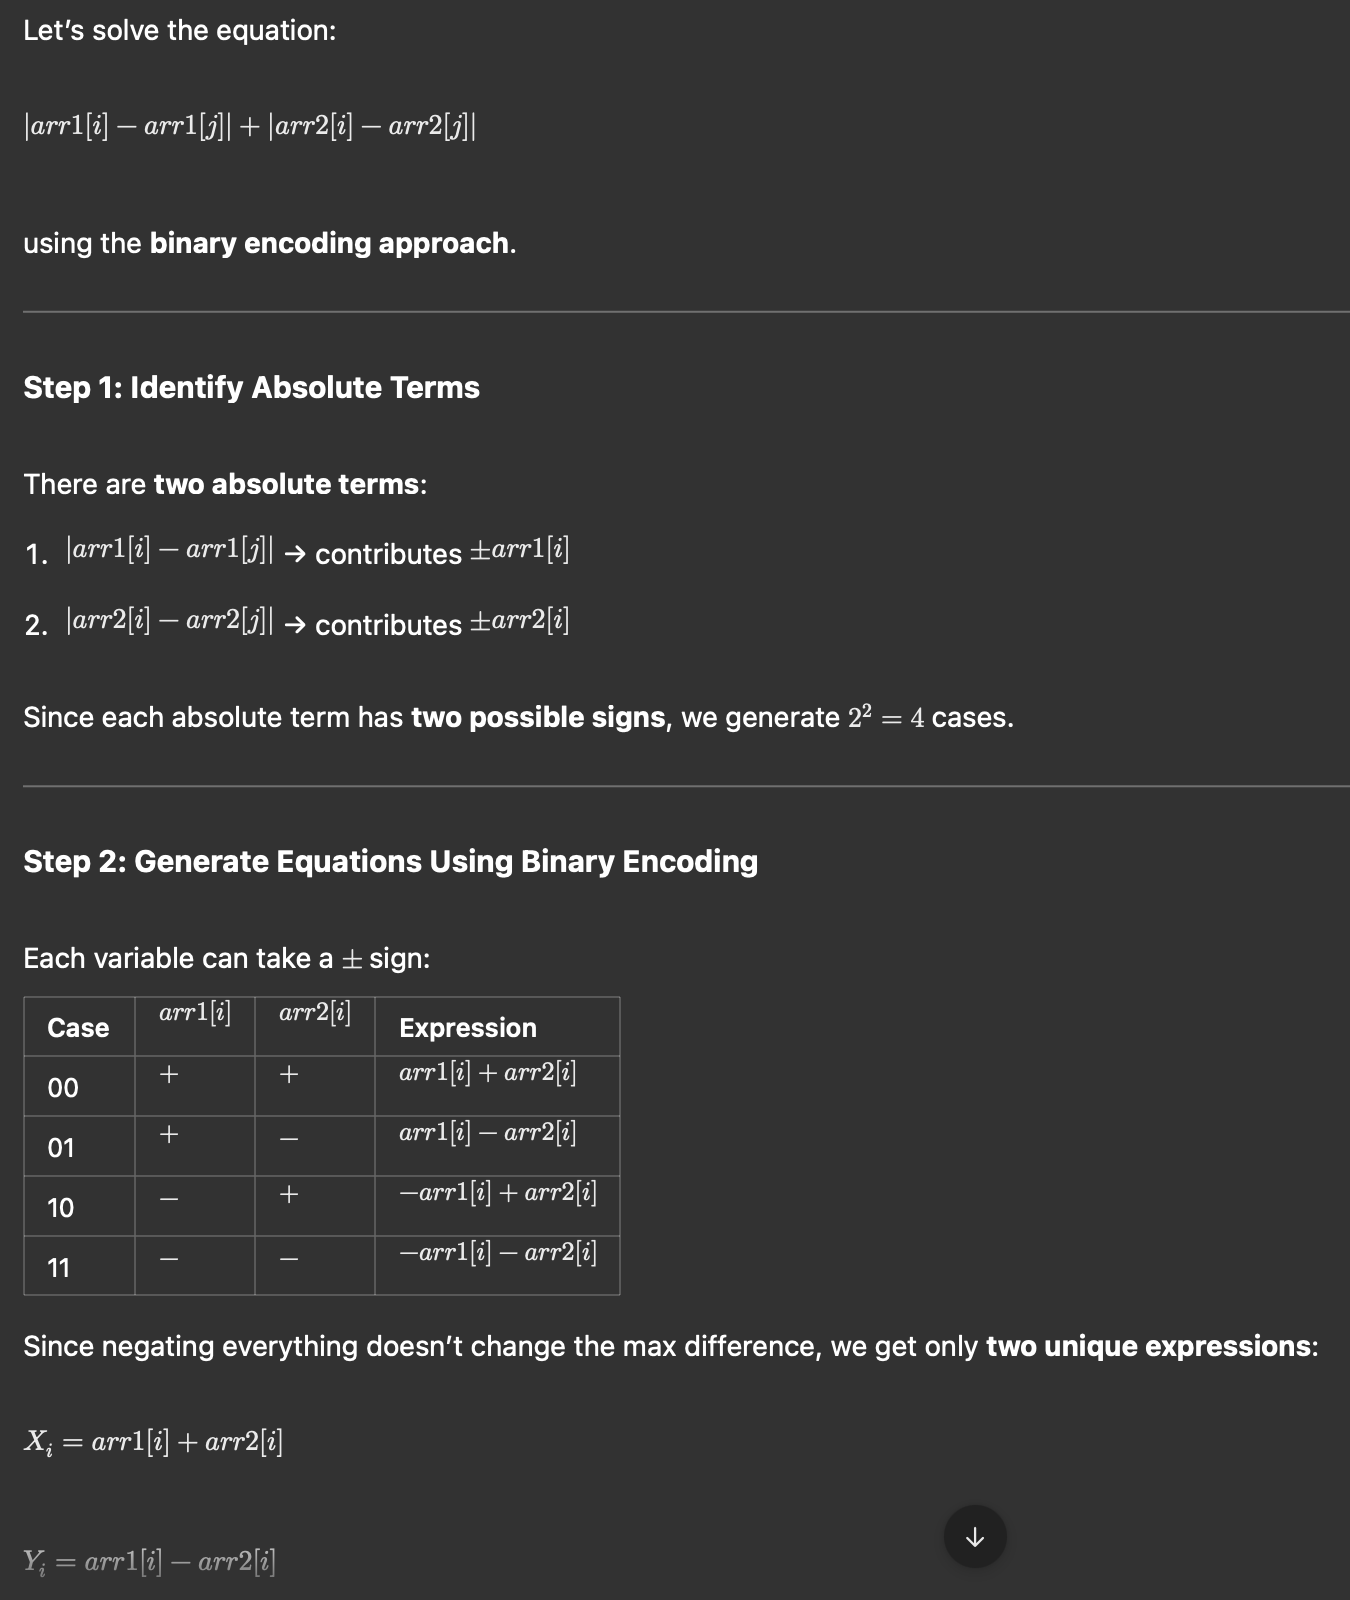
final_answer = max(max(X) - min(X), max(Y) - min(Y))


In [ ]:
Question 4: Rain Water trapped on each building
A = [3, 1, 2, 4, 0, 1, 3, 2]

left_prefix = [3, 3, 3, 4, 4, 4, 4, 4]
right_prefix = [4, 4, 4, 4, 3, 3, 3, 2]
answer= take min of each left_preix and right_prefix - A[i]

Solution 2: Two pointer approach
Idea: To calculate answer we either use left max or right max - A[i]

def max_trapped_water(buildings):
    """ We increment the samller of left/right pointer.
         - Water will only store if left_max is higher than the current building size.
         - else (when current is equal or higher than the left_max then no water will be stored)
    """ 
    if not buildings or len(building s) < 3:
        return 0  # No trapping possible if there are less than 3 buildings

    left, right = 0, len(buildings) - 1
    left_max, right_max = buildings[left], buildings[right]
    water = 0

    while left < right:
        if buildings[left] < buildings[right]:
            if buildings[left] >= left_max:
                left_max = buildings[left]
            else:
                water += left_max - buildings[left]
            left += 1
        else:
            if buildings[right] >= right_max:
                right_max = buildings[right]
            else:
                water += right_max - buildings[right]
            right -= 1

    return water

In [ ]:
Bucket Sort: 
Based on PigeonHole Principle: if you have more pigeons than pigeonholes, and you try to place each pigeon into a hole, at least one hole must contain more than one pigeon.”

Idea: If bucket size is G which is the min gap b/w two elements, then no buckets can have elements with diff greater than G.

Question Identification:
 - When numbers are uniformly distributed and are within a given range ([0, 100])
 - Finding gaps or require efficient sorting

Algo: Place all numbers in almost N-1 buckets. It places all the numbers in evenly distributed buckets.
    - Each bucket only stores min and max values of the bucket ranges.
    - the max gap would exist, b/w 2 numbers like max of bucket A and min of bucket C, if all middle buckets are empty
    - Ans diff b/w max and min: [max()] ,  [empty_bucket], [min()]

import math

def maximum_gap(arr):
    """ Each bucket size: max(1, (max_value - min_value) // N -1)
        Bucket count: ((max_value - min_value) // bucket_count) + 1
        bucket_index : (max_value - min_value) // bucket_size
    """
    if len(arr) < 2:
        return 0

    min_val, max_val = min(arr), max(arr)
    N = len(arr)

    # Step 2: Compute bucket size and count
    bucket_size = max(1, (max_val - min_val) // (N - 1))
    bucket_count = (max_val - min_val) // bucket_size + 1

    # Step 3: Create buckets
    buckets = [[math.inf, -math.inf] for _ in range(bucket_count)]

    # Step 4: Place elements into buckets
    for num in arr:
        index = (num - min_val) // bucket_size
        buckets[index][0] = min(buckets[index][0], num)  # min in bucket
        buckets[index][1] = max(buckets[index][1], num)  # max in bucket

    # Step 5: Compute max gap
    max_gap = 0
    prev_max = min_val

    for min_val, max_val in buckets:
        if min_val == math.inf:  # Empty bucket
            continue
        max_gap = max(max_gap, min_val - prev_max)
        prev_max = max_val

    return max_gap

# Example Run
arr = [1, 2, 3, 4, 100]
print(maximum_gap(arr))  # Output: 96



Question 6: Sort all numbers in O(N), if range is b/w min & max is small.
def range_sorting(arr, K):
    # Sorting in O(N), when range of values is small/ given.
    buckets = [0] * (K + 1)
    for num in arr:
        buckets[num] += 1

    # Step 3: Construct the sorted array
    sorted_arr = []
    for num in range(K + 1):
        sorted_arr.extend([num] * buckets[num])  # Append 'num' multiple times

    return sorted_arr

# Example usage:
arr = [5, 3, 7, 1, 9, 3, 3, 5]
K = 9  # Maximum possible value in the array
sorted_arr = bucket_sort(arr, K)
print("Sorted Array:", sorted_arr)

In [ ]:
Questions 7: Given a 2D matrix, find sum of all possible rectangles.
Idea: A rectangle is formed by 2 points
    All rectangeles where where X cell is part of, will have start point (in upper green area) and end point in lower area (yellow marked)
    To get all starting points: (x+1) * (y+1) (ie. a starting point can be 1, 2, 3, 4, 5, ..) in image.
    To get all end points (N-i) * (M-j)

def sum_of_all_rectangles(matrix):
    N, M = len(matrix), len(matrix[0])  # Get dimensions
    total_sum = 0

    for i in range(N):
        for j in range(M):
            contribution = matrix[i][j] * (i + 1) * (j + 1) * (N - i) * (M - j)
            total_sum += contribution

    return total_sum


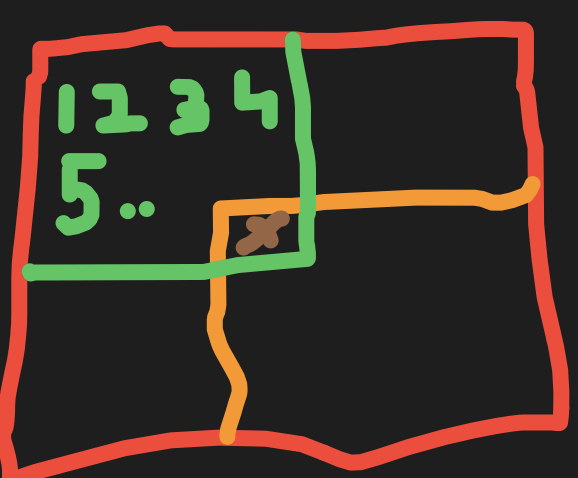

In [12]:
#Concept: Prefix sum array

A = [1,2,3,4,5,6,7]
prefix_A = [1,3,6,10,15,21,28]

sum([2, 3, 4]) == prefix_A[3] - prefix_A[1-1]


# Concept: Discarding the elements in sorted arrays.
- In a 2D sorted array, find the position of an elements.  Move from top-right, if current value is higher than the given move Column -1, else Row -1

# Use indexes
- Given an unsorted array from 0 to N-1 elements, sort the array.
  Sol: Values are similar to indexes, Move from left keep track of max till now, if max is equal to index, then create a new bucket.
      Sort each individual buckets and join all for answer.

True

In [5]:
Given sorted 2D matrix, find a matrix having maximum sum.
-5 -4 -1
-3  2  4
 2  5  8.

Sol: Our answer must have the right-bottom value (8).
Create a prefix 2D matrix from right-bottom (X,Y) to (0,0). Iterate over the array and find the maximum value.


5

# GCD

In [ ]:
gcd(x,y): answer range [1, min(x,y)]
- gcd(15, 5) = 5
- gcd(15, 0) = 15
- gcd(15, 1) = 1
- gcd(a,b,c) = gcd(a, gcd(b,c))
- gcd can never be zero

def gcd(a, b):
    """ TC: Log(min(a,b))
         As with each operation, we will divide the number half or less.
    """
    if a == 0 and b == 0:
        raise Exception("error")
    if b == 0:
        return a
    if b > a:
        return gcd(a, b % a)
    return gcd(b, a % b)

# Example usage
num1 = 48
num2 = 18
print("GCD:", gcd(num1, num2))  # Output: GCD: 6

In [13]:
10 % 3

1

In [16]:
Question: Find GCD of factorial of all numbers in array
    - answer: min(A)!
    - 1 x 2 x 3 x 4 x Y will be common in all factorials, where Y is min of array.

Question: Delete one element from array, and find max GCD of remaining array such that it is maximized (ie. max( GCD(A ~ A[i]) ) 
Concept: Prefix and postfix GCD arrays
   - Iterate over array, and keep max of GCD( Prefix_GCD(A[i-1], Postfix_GCD(A[i+1])
   [               i          ]
   -> Pefix GCD                <- Postfix GCD


Question: Add a few numbers in array, such that any two number diff also exist in array.
   - Take GCD of array -> G
      [g, 1*g, 2*g, 3*g, ..array_elements...]

Question: Given a 2D matrix, find shortest path to move from (x,y) to (1,1).
 Possilbe steps allowed: (x, y+x) and (x+y, y)
Sol: Move in reverse direction
x,y                                                          
  - move either (x-y, y) when x is greater                                                  
  - or move (x, y-x)       
- Ans: No. of iterations.

Via GCD:
  - Calculate gcd(x,y)
    - if answer is (1,1) then only we can reach.
    - No. of jumps: count += y//x while calculating gcd(x, y%x)                                                         

3

# Factors

In [ ]:
- Factors of 60
[1, 2, 3, 4, 5, 6 |  10, 12, 20, 30, 60]
- all factors are less than sqrt(60)
- if N is a perfect square like 9, like it will have odd number of factors.

Question 1: Find all factors of N    
def find_factors(n):
    """ TC: sqrt(N)
    """ 
    factors = set()  # Using a set to avoid duplicates
    i = 1
    while i * i <= n:  # Loop until i^2 ≤ N
        if n % i == 0:
            factors.add(i)
            factors.add(n // i)  # Add both divisors
        i += 1
    return sorted(factors)  # Sorting to return factors in order


Question 2: Door close problem, Initialy all door are closed.
1 st move: toggle every 1st door
2nd move: toggle every 2nd door
3rd move: toggle every 3rd door

for 6 door: [1, 2, 3, 6] total even factors, door will remain in same state.
for 9th door: [1, 3, 9] It will change the state, as odd no. of factors.

We just need to find all perfect sqare roots.

In [ ]:
# Chekc if number is Prime numbers
def check_prime(N):
    i = 2
    while i * i <= N:
        if N % i != 0:
            return False
    return True

# Print all prime numbers
# Stieve of Eratothesis:
  1. Assume all numbers are prime numbers.
  2. Then remove if are multiple of any number

def sieve_of_eratosthenes(n):
    if n < 2:
        return []

    is_prime = [True] * (n + 1)
    is_prime[0], is_prime[1] = False, False

    for p in range(2, int(n**0.5) + 1):
        if is_prime[p]:
            for multiple in range(p * p, n + 1, p):  # Mark all multiples of p
                is_prime[multiple] = False

    # Step 4: Collect all prime numbers
    return [num for num, prime in enumerate(is_prime) if prime]

# No. of factors
720 = 2^4 * 3^2 * 5^1
No. of factors = (4+1) * (2+1) * (5+1) = 30
        

In [ ]:

(a+b) % c = (a%c + b%c) %c
(a*b) % c = (a%c) * (b%c)
FermatN^(P-1) % P = 1


Question 1: Solve (A^b) % c
def solve(a,b,c):
    ans = 1
    while (b > 0):
        if (b%2 == 0):
            a = (a*a) % c
            b = b / 2
        else:
            b -=1
            ans = (ans * A) % c

Question 2: N^100000 % 5 => (N^4)^2500 % 5 => 1

Question 3: A function generate a no. from [1 to 6] with equal probability. Define a function that generates [1 to 18] with equal probability.
 Sol: Define 3 buckets [1, 6] [7, 12] [13, 18], and another function to select the bucket.
    final_ans = (Given_fun() % 3) * Given_fun().  => [1, 2, 3] * [1,2,3,4,5,6]





In [ ]:
# Bit Manipulation
- 0^1 = 1 (XOR gives 1 only when both bits are different)
- a ^ a = 0
- a ^ 0 = a
- if, (a^b)=k then (a^k)=b

- Left Shift all bits by i places (n<<i). It multiply the number by 2^i
   0001 << 1   =>   0010

- Right shift all bits by i places (n>>i). It divide the number by 2^i
  0100 (4)  >> 1  => 0010 (2)

- To check ith bit is set or not
  00110 (6) N
  00010 (2) (1<<i) i=1
----------- &
  00010 (2) if this number is greater than 0, then ith bit is set

# To check ith bit is set or not
 - N ^ (1<<i)) > 0
 - ith bit is set, if (N & (1<<i)) is greater than zero

# To set ith bit in the result
 - result |= (1 << i)

Concept: If number in array are appearing even times, takes xor of array will cancel out all even times numbers.


Time complexity:
 N * range(32) => N * log M (where M is max number)

Question 1: A ^ B = k, k is given. find A and B
 - if A^B=k, then A^k=B
def find_xor_pair(arr, k):
    """  iterate over array, and check if A^k exist in hashmap, and always add the given array value in hashmap.
    """
    seen = set() 
    for a in arr:
        b = a ^ k  # Compute B using A ⊕ K
        if b in seen:
            return (b, a)  # Return pair found
        seen.add(a)  # Store A for future checking
    return None 


Question 2: In array 2 numbers are appearing once, and rest of numbers are appearing twice.
Sol: Take XOR of all numbers, we will get the k, and we need to find a and b.
a ^ b = k
Check k for least significant bit, set a 1. Now that means either a or b will have that bit as 1.
divide all the array numbers into 2 buckets 
1st bucket: all numbers in array with ith bit as 1.
2nd bucket: all nummber from array with ith bit as 0.

Take XOR of each bucket, we will get the a and b.

def find_two_unique_numbers(arr):
    xor_value = 0
    right_most_set_bit_index = 0
    a = b = 0 # buckets
    for num in arr:
        xor_value ^= num

    # find right most set bit
    for i in range(0,32):
        if (xor_value ^ (1<<i)) > 0:
            right_most_set_bit_index = i
            break
            
    # split numbers into 2 buckets
    for num in arr:
        if num & (1<< right_most_set_bit_index) > 0:
            a ^= num
        else:
            b ^= num
    return (a,b)

find_two_unique_numbers([4, 7, 9, 4, 2, 9])


Question 3: There are numbers repeated 3 times, and just one number appear once.
def find_unique_number(arr):
    """ Concept: Construct number bit by bit: Iterate on each bit from right to left, if sum of set bit % 3 ==0, then ignore, else set that bit to construct the result number.
    """
    result = 0
    
    # Iterate through each bit position (0 to 31 for integers)
    for i in range(32):
        bit_count = 0
        
        # Count how many numbers have the i-th bit set
        for num in arr:
            if num & ( 1 << i):
                bit_count += 1
        
        # If bit_count is not a multiple of 3, it belongs to the unique number
        if bit_count % 3 != 0:
            result |= (1 << i)  # Set the i-th bit in the result
            
    return result

# Example usage:
arr = [5, 5, 5, 7, 9, 9, 9]
print(find_unique_number(arr))  # Output: 7

In [34]:
Concept: Closer numbers have minimum XOR

Question 4: Given an array, find two numbers having minimum XOR.
def min_xor_pair(arr):
    arr.sort()  # Step 1: Sort the array
    min_xor = float('inf')
    pair = None
    
    # Step 2: Find min XOR between consecutive numbers
    for i in range(len(arr) - 1):
        xor_value = arr[i] ^ arr[i + 1]
        if xor_value < min_xor:
            min_xor = xor_value
            pair = (arr[i], arr[i + 1])
    
    return pair, min_xor

# Find hamming distance, ie number of bits changes
def hamming_distance_optimized(nums):
    total_distance = 0
    n = len(nums)

    for bit in range(32):  # Check all 32-bit positions
        count_ones = sum((num >> bit) & 1 for num in nums)
        count_zeros = n - count_ones
        total_distance += count_ones * count_zeros  # Each pair contributes
    
    return total_distance

# Example
print(hamming_distance_optimized([4, 14, 2]))  # Output: 6

7


# Binary Search

In [31]:
Binary Search: To search an element in a sorted array. 
TC: log N (base 2: as we eliminate half of the numbers in each step).

# Template
def binary_search(arr, target):
    """
    """
    result = -1
    left, right = 0, len(arr) - 1

    while left <= right:
        mid = left + ((right - left) // 2)
        
        if arr[mid] == target:  
            result = mid  
        
        elif arr[mid] < target:  
            left = mid + 1
        
        else:  
            right = mid - 1

    return result


Question 1: Find first occurance of an element
- Move left even if exact match found.
        if arr[mid] == target:
            result = mid  # Potential answer
            right = mid - 1

Question 2: Find last occurance of an element
- Move left even if exact match found.
        if arr[mid] == target:
            result = mid  # Potential answer
            right = mid + 1

Question 3: Find closest smaller or equal to k
- Remove exact match condition, as we might not 
    while left <= right:
        mid = left + (right - left) // 2
        if arr[mid] == target:
            ans = mid
            right = mid - 1
            
        if arr[mid] > target:
            ans = mid # We might not get the answer in exact match, so set the answer in other condition as well.
            right = mid - 1
        else:
            left = mid + 1

3

In [ ]:
Concept: In a sorted rotated array, either left half or right half will be sorted.
Concept: Draw a number line for an array.

    
# Question 4: Search an element in a sorted array.
def search_in_rotated_sorted_array(arr, target):
    low, high = 0, len(arr) - 1

    while low <= high:
        mid = (low + high) // 2

        # If the element is found
        if arr[mid] == target:
            return mid

        # Left half is sorted
        if arr[low] <= arr[mid]:
            if arr[low] <= target < arr[mid]:  # Target in left half
                high = mid - 1
            else:  # Target in right half
                low = mid + 1
        # Right half is sorted
        else:
            if arr[mid] < target <= arr[high]:  # Target in right half
                low = mid + 1
            else:  # Target in left half
                high = mid - 1

    return -1  # Element not found


In [ ]:
Bianry Search Variation 2:
Within while loop, if we are using value of mid, like (low = mid) or (high = mid).
then to avoid infinite loop, we should use while low < high
In any case, low = mid +-1, it cannot be  low = mid


def find_peak_binary(arr):
    """ check mid > mid +1, if it satisfy the condition then assign mid or mid+1 as low or high pointer.
        In the end, left and right will be equal.
    """
    low, high = 0, len(arr) - 1

    while low < high:
        mid = (low + high) // 2

        if arr[mid] > arr[mid + 1]:  # Peak is on the left
            high = mid
        else:  # Peak is on the right
            low = mid + 1

    return low  # Peak index



Question: In array all elements are repeated twice, except one
Sol 1: take XOR of array
Sol 2: two elements of same value, first should be on even index, and second one on odd index.

def find_single_element(arr):
    low, high = 0, len(arr) - 1

    while low < high:
        mid = low + (high - low) // 2

        # Make sure mid is even (for easy comparison with mid+1)
        if mid % 2 == 1:
            mid -= 1
        
        if arr[mid] == arr[mid + 1]:
            low = mid + 2  # Move right
        else:
            high = mid  # Move left

    return arr[low]  # Single element found

# Example usage
arr = [1, 1, 2, 2, 3, 4, 4, 5, 5]
print(find_single_element(arr))  # Output: 3


In [ ]:
# Binary Search on Answer Space
TC: log (size of answer space) * feasibility check

key points to identify problems:
1. The answer lies in the know range, we can define answer min and max vaulue or range.
2. Problem follows a monotonic fuction, If an answer X is valid, then all answers ≤ X (or ≥ X) are also valid.
3. Feasibility check, to check if an answer if possible or not, it usually takes O(N)

Problem Type
Min & Max Answer Range                               Condition to Check in Binary Search
1. 1 to N                                                        Max Subarray Size with Sum <= X        
2. min(N) to Max(N)                                              K-th smallest/largest element
3. given constraints                                             Smallest/largest feasible value
4. 1 to max(arr)                                                 Min/Max speed, time, distance, etc.                           
5. max(arr) to sum(arr)                                          Split array into K subarrays (e.g., minimize largest sum).     


Example 1: Minimize Largest Subarray Sum (Split Array). Split into K sub-arrays.
ans range: [max(N), sum(N)]

def can_split(arr, k, max_sum):
    subarrays, curr_sum = 1, 0
    for num in arr:
        if curr_sum + num > max_sum:
            subarrays += 1
            curr_sum = num
            if subarrays > k:
                return False
        else:
            curr_sum += num
    return True

def min_largest_split_sum(arr, k):
    """TC: O(N log(sum(arr) - max(arr)))
    """
    left, right = max(arr), sum(arr)
    while left < right:
        mid = (left + right) // 2
        if can_split(arr, k, mid):
            right = mid
        else:
            left = mid + 1
    return left


In [ ]:
Example 2: 
here we are working 0.000 precesion, so right and left = mid, instead of +-1.
and while condition is right-left > 1e-6

def min_max_gas_distance(stations, K):
    
    def is_possible(d):
        """ Check if we can place <= K stations such that max distance <= d """
        count = 0  # Number of additional stations needed
        for i in range(len(stations) - 1):
            gap = stations[i + 1] - stations[i]  # Distance between adjacent stations
            count += int(gap / d)  # Number of stations needed in this gap
        return count <= K  # True if we can place K or fewer stations

    # Define the binary search range
    left, right = 0, stations[-1] - stations[0]  # Max possible distance

    # Precision threshold (since we're dealing with floating points)
    eps = 1e-6  # Stop when the difference is very small

    while right - left > eps:
        mid = (left + right) / 2.0
        if is_possible(mid):
            right = mid  # Try to minimize distance
        else:
            left = mid

    return left  # Return the minimized maximum distance

# Example usage
stations = [1, 2, 4, 8, 9]
K = 3
print(min_max_gas_distance(stations, K))  # Expected Output: Smallest max distance possible

In [ ]:
Question 5: Place N cows, such that the distance b/w the two is maxmimized

def can_place_cows(stalls, C, min_dist):
    """Check if we can place C cows with at least 'min_dist' between them."""
    count = 1  # Place the first cow at the first stall
    last_pos = stalls[0]  # Track last placed cow

    for i in range(1, len(stalls)):
        if stalls[i] - last_pos >= min_dist:
            count += 1  # Place a cow here
            last_pos = stalls[i]  # Update last position
            
            if count == C:  # If all cows are placed, return True
                return True
    return False  # Not possible with this min_dist

def aggressive_cows(stalls, C):
    stalls.sort()  # Ensure stalls are sorted for correct placements

    left, right = 1, stalls[-1] - stalls[0]  # Min & Max possible distances
    best_dist = 0  # Store best answer

    while left <= right:
        mid = (left + right) // 2  # Middle distance to check
        if can_place_cows(stalls, C, mid):
            best_dist = mid  # Valid distance, try a larger one
            left = mid + 1
        else:
            right = mid - 1  # Reduce search space

    return best_dist  # Maximum possible minimum distance

# Example Usage
stalls = [1, 2, 4, 8, 9]
C = 3
print(aggressive_cows(stalls, C))  # Expected Output: 3

In [ ]:
Question 6: Minimize the maximum number of pages are allocated to S students

ans range: [max(N), sum(N]
Min range: if we just assign one book: min no. of pages assigned to a student would be max(N)
Max range: if we assign all the books to just one student.



Concept: Whenever we divide a solution into multiple cases.
1. There should be no data point that lies in more than one case.
2. Mutually Exhaustive: All the possiblity must be covered in atleast one of case.

# Arrays

In [42]:
Question 1: Merge overlapping intervals

intervals = [[1, 3], [8, 10], [2, 6], [15, 18]]
def merge_intervals(intervals):
    result = [intervals[0]]
    intervals.sort(key= lambda x: x[0])

    for i in range(1, len(intervals)):
        new_low, new_high = intervals[i]
        res_low, res_high = result[-1]

        if (res_high >= new_low):
            result[-1][1] = max(res_high, new_high) # adding max() will work for an interval that lies completely in b/w [2,3]
        else:
            result.append(intervals[i])
        
    return result

merge_intervals(intervals)




[[1, 6], [8, 10], [15, 18]]

In [ ]:
Question 2: Print count of "AG" from a string
Sol 1: Create a postfix of G array, and iterate from left to right with each A, just add the count of G
ABCGAG
222211     <- postfix of G count

Sol 2: A B C G A G
             +1  +2
Iterate from left to right, maintain the count of A, with each G add the count of A to result.

In [ ]:
Question 3: From an unsorted array, find the first missing number
Sol 1: Create a new empty array, and then iterate over given array, if number is positive new_arr[number] = True
   Idea: to fill a new empty array based on the index. so, index will be equal to number.

Sol2: use the same array, and swap a positive number to it's correct index.

def first_missing_positive(arr):
    """Sol 2
    """
    n = len(arr)
    
    # Step 1: Place each number in its correct index
    i = 0
    while i < n:
        correct_index = arr[i] - 1  # Correct index for arr[i]
        if 1 <= arr[i] <= n and arr[i] != arr[correct_index]:  
            arr[i], arr[correct_index] = arr[correct_index], arr[i]  # Swap
        else:
            i += 1  # Move to next number

    # Step 2: Find the first missing positive
    for i in range(n):
        if arr[i] != i + 1:
            return i + 1  # First missing positive number

    return n + 1  # If all numbers from 1 to N are present

# Example Usage:
arr = [3, 4, -1, 1]
print(first_missing_positive(arr))  # Output: 2

arr = [1, 2, 0]
print(first_missing_positive(arr))  # Output: 3

# Sorting

In [ ]:
# Merge Sort
def mergeSort(arr):
    if len(arr) <= 1:
        return arr

    mid = len(arr) // 2
    left = mergeSort(arr[:mid])    # Sort left half
    right = mergeSort(arr[mid:])   # Sort right half

    return merge(left, right)

def merge(left, right):
    merged = []
    i = j = 0

    # Merge the two sorted halves
    while i < len(left) and j < len(right):
        if left[i] < right[j]:
            merged.append(left[i])
            i += 1
        else:
            merged.append(right[j])
            j += 1

    # Add remaining elements
    merged.extend(left[i:])
    merged.extend(right[j:])
    
    return merged

# Example
arr = [5, 2, 4, 7, 1, 3, 6]
sorted_arr = mergeSort(arr)
print("Sorted Array:", sorted_arr)

In [ ]:
# Two pointer approach
- Find smallest sub-array that needs to be sorted, that makes the complete array sorted.
- Given sorted array, find any pair with sum=x

# Question: Two sum problem
def findPairWithSum(arr, x):
    i = 0
    j = len(arr) - 1

    while i < j:
        current_sum = arr[i] + arr[j]
        if current_sum == x:
            return (arr[i], arr[j])
        elif current_sum < x:
            i += 1
        else:
            j -= 1

    return "No pair found"

# Question: Three sum problem

def findTripletWithSum(arr, P):
    n = len(arr)
    for i in range(n-2):
        # Fix A[i]
        j = i + 1
        k = n - 1

        while j < k:
            current_sum = arr[i] + arr[j] + arr[k]
            if current_sum == P:
                return (arr[i], arr[j], arr[k])
            elif current_sum < P:
                j += 1
            else:
                k -= 1

    return "No triplet found"

In [ ]:
def subarraySumExists(arr, X):
    """ Using: Prefix sum array and a hash map
    """
    prefix_sum = 0
    seen = set()

    for num in arr:
        prefix_sum += num
        if prefix_sum == X or (prefix_sum - X) in seen:
            return True
        seen.add(prefix_sum)

    return False


def subarraySumExists(arr, X):
    """ Find a sub-array with sum = X.
        Using two pointer approach, starting from [0,0]
    """
    start = 0
    current_sum = 0

    for end in range(len(arr)):
        current_sum += arr[end]

        # Shrink the window if sum exceeds X
        while current_sum > X and start <= end:
            current_sum -= arr[start]
            start += 1

        # Check if current sum equals X
        if current_sum == X:
            print(f"Subarray with sum {X} exists from index {start} to {end}")
            return True

    print(f"No subarray with sum {X} exists.")
    return False


def longestSubstringWith2Distinct(s):
    """ Find longest substring with 2 distinct characters.
        Using, two pointer approach starting from [0,0]
    """
    start = 0
    max_len = 0
    char_count = {}

    for end in range(len(s)):
        # Add character to map
        char = s[end]
        char_count[char] = char_count.get(char, 0) + 1

        # Shrink window if more than 2 distinct chars
        while len(char_count) > 2:
            char_count[s[start]] -= 1
            if char_count[s[start]] == 0:
                del char_count[s[start]]
            start += 1

        # Update max length
        max_len = max(max_len, end - start + 1)

    return max_len

# Example
s = "eceba"
print("Max length substring with at most 2 distinct characters:", longestSubstringWith2Distinct(s))



def trap(height):
    """ Rain water problem
        Using, 2 pointer approach
        - Keep two variables → left_max and right_max to store the maximum height till left and right.
    """
    n = len(height)
    left, right = 0, n - 1
    left_max, right_max = 0, 0
    water = 0

    while left <= right:
        if height[left] <= height[right]:
            if height[left] >= left_max:
                left_max = height[left]
            else:
                water += left_max - height[left]
            left += 1
        else:
            if height[right] >= right_max:
                right_max = height[right]
            else:
                water += right_max - height[right]
            right -= 1

    return water

# Example
arr = [4, 2, 0, 3, 2, 5]
print("Total trapped water:", trap(arr))


def maxStatues(cave, statues):
    """ Question: Given 2 arrays, height of cave and height of statues and we want to put maximum number of statues in the cave
    """
    cave.sort()
    statues.sort()

    i, j = 0, 0
    count = 0

    while i < len(cave) and j < len(statues):
        if statues[j] <= cave[i]:
            count += 1
            j += 1
            i += 1
        else:
            i += 1  # Move to next cave slot

    return count

# Example
cave = [4, 3, 5, 2]
statues = [2, 3, 4]
print("Max statues placed:", maxStatues(cave, statues))

# Question: Find A[i]==[A[j], where i-j is minimized.
Use a hashmap, to store last occurance index of any element, 


In [ ]:
Question: Find the largest size of subarray of sum=0, Array can have negative as well.

Idea: 
             0. 1. 2. 3. 4. index
Prefix sum: [1, 2, 4, 7, 2]
Here, first 2 occurs at index 1 and next at index 4, which means the sub-array from index [1, 2, 3, 4] will have a sum zero.
So, 

def longestSubarrayWithZeroSum(arr):
    prefix_sum = 0
    max_len = 0
    sum_index = {}

    for i in range(len(arr)):
        prefix_sum += arr[i]

        if prefix_sum == 0:
            max_len = i + 1  # from 0 to i

        if prefix_sum in sum_index:
            length = i - sum_index[prefix_sum]
            max_len = max(max_len, length)
        else:
            sum_index[prefix_sum] = i

    return max_len

# Example
arr = [1, 2, -3, 3, -1, -2, 4, -4]
print("Length of longest subarray with sum 0:", longestSubarrayWithZeroSum(arr))

In [ ]:
# Custom Sorting in python
order_map = {ch: i for i, ch in enumerate(order)}
sorted_s = ''.join(sorted(s, key=lambda x: order_map.get(x, -1)))

def customSort(order, s):
    # Step 1: Count frequency
    freq = {}
    for ch in s:
        freq[ch] = freq.get(ch, 0) + 1

    # Step 2: Build the result based on given order
    result = []
    for ch in order:
        if ch in freq:
            result.extend([ch] * freq[ch])

    return ''.join(result)

# Example
order = "acbr"
s = "bcarabrca"
print("Sorted string:", customSort(order, s))

In [ ]:


def sortZeroOne(arr):
    """ Question: Sort [0, 1] in array
    """
    left = 0
    right = len(arr) - 1

    while left < right:
        if arr[left] == 1 and arr[right] == 0:
            arr[left], arr[right] = arr[right], arr[left]
            left += 1
            right -= 1
        if arr[left] == 0:
            left += 1
        if arr[right] == 1:
            right -= 1

    return arr

def sortZeroOneTwo(arr):
    """Question: Sort [0,1,2]
    """
    low, mid, high = 0, 0, len(arr) - 1

    while mid <= high:
        if arr[mid] == 0:
            arr[low], arr[mid] = arr[mid], arr[low]
            low += 1
            mid += 1
        elif arr[mid] == 1:
            mid += 1
        else:  # arr[mid] == 2
            arr[mid], arr[high] = arr[high], arr[mid]
            high -= 1

    return arrv

In [ ]:
Question: given two array of X, Y coordinates, find maximum points lie in one line.

from collections import defaultdict
from math import gcd

def maxPoints(X, Y):
    n = len(X)
    if n <= 2:
        return n

    max_points = 0

    for i in range(n):
        slope_count = defaultdict(int)
        duplicate = 0
        curr_max = 0

        for j in range(n):
            if i == j:
                continue

            dx = X[j] - X[i]
            dy = Y[j] - Y[i]

            if dx == 0 and dy == 0:
                duplicate += 1
                continue

            g = gcd(dx, dy)
            if g != 0:
                dx //= g
                dy //= g

            slope_count[(dx, dy)] += 1
            curr_max = max(curr_max, slope_count[(dx, dy)])

        max_points = max(max_points, curr_max + duplicate + 1)

    return max_points

# Example
X = [1, 2, 3, 4, 5]
Y = [1, 2, 3, 4, 5]
print("Max points on a line:", maxPoints(X, Y))

# Sliding Window

In [ ]:
Problem Identification:
- Given an array or sting, question is about sub-array or sub-string.
- Window size is either given or asked.

Questions are related to sub-array mostly.
- Fixed size window
- Variable size window

Question: Maximum sum sub-array of size k
def max_sum_subarray_k(arr, k):
    n = len(arr)
    if n < k:
        return -1  # Not enough elements

    # Initial window sum
    window_sum = sum(arr[:k])
    max_sum = window_sum

    start = 0
    end = k

    while end < n:
        window_sum += arr[end] - arr[start]
        max_sum = max(max_sum, window_sum)

        start += 1
        end += 1

    return max_sum


    

In [ ]:
# Sliding Window Template

# When window size is less than K, then just increase J to hit window size of K
# Each if else case should have, j++
while (j < size):
    # Basic calculations

    # If window size is less than K
    if (j-i +1 < K):
        j++

    else if (j-i+1 == K):
        - Calculate the answer
        - Remove i
        - Slide and maintain the window size.
        - j++
            



Question: Print first negative number of every window of size k.
from collections import deque

def first_negative_in_window_k(arr, k):
    i = 0
    j = 0
    n = len(arr)
    result = []
    dq = deque()  # stores index of negative numbers

    while j < n:

        # If current element is negative, store its index
        if arr[j] < 0:
            dq.append(j)

        # When window size is less than k
        if (j - i + 1) < k:
            j += 1

        # When window size is exactly k
        elif (j - i + 1) == k:
            # Append the first negative number or 0
            if dq:
                result.append(arr[dq[0]])
            else:
                result.append(0)

            # Slide the window: remove index if it is out of window
            if dq and dq[0] == i:
                dq.popleft()

            i += 1
            j += 1

    return result
    

In [15]:
# Print number of anagrams of a given string, of window of size k

def count_anagrams(K, A):
    i = 0
    j = 0
    n = len(A)
    k = len(K)
    result = 0

    freq = {}
    for ch in K:
        freq[ch] = freq.get(ch, 0) + 1
    count = len(freq) # To maintain number of unique characters

    while j < n:
        # Process incoming character A[j]
        if A[j] in freq:
            freq[A[j]] -= 1
            if freq[A[j]] == 0:
                count -= 1 # Decrease count, as no. of unique characters are decrease by 1.

        # When window size is less than k
        if (j - i + 1) < k:
            j += 1

        # When window size is exactly k
        elif (j - i + 1) == k:
            # If all character counts matched
            if count == 0:
                result += 1

            # Before sliding the window, handle A[i]
            if A[i] in freq:
                if freq[A[i]] == 0:
                    count += 1
                freq[A[i]] += 1

            i += 1
            j += 1

    return result

# Example usage
K = "aaba"
A = "aabaabaa"
print(count_anagrams(K, A))  # Output: 4


[1, 2, 3, 4, 5]

In [ ]:
Question: Print maximum of sub-array of size k
from collections import deque

def max_in_all_windows_k(arr, k):
    i = 0
    j = 0
    n = len(arr)
    result = []
    dq = deque()  # Will store indices of elements

    while j < n:
        # Remove all elements smaller than current from the back
        while dq and arr[dq[-1]] < arr[j]:
            dq.pop()
        
        dq.append(j)

        # When window size is less than k
        if (j - i + 1) < k:
            j += 1

        # When window size is exactly k
        elif (j - i + 1) == k:
            # Append the front (max) element of current window
            result.append(arr[dq[0]])

            # Slide the window: remove the index if it’s out of the window
            if dq and dq[0] == i: 
                dq.popleft()

            i += 1
            j += 1

    return result


In [18]:
# Variable size sliding window

Question: Find longest sub-array of sum k 
def longest_subarray_sum_k_positive(arr, k):
    i = 0
    j = 0
    n = len(arr)
    max_len = 0
    total = 0

    while j < n:
        total += arr[j]

        if total < k:
            j += 1
        elif total == k:
            max_len = max(max_len, j - i + 1)
            j += 1
        else:
            while total > k:
                total -= arr[i]
                i += 1
            if total == k:
                max_len = max(max_len, j - i + 1)
            j += 1

    return max_len

0


In [ ]:

Question: Print longest substring with unique characters of any size.
def lengthOfLongestSubstring(s):
    freq = {}
    left = 0
    right = 0
    res = 0

    while right < len(s):
        ch = s[right]
        freq[ch] = freq.get(ch, 0) + 1

        # If current char causes a duplicate, shrink window from left
        while freq[ch] > 1:
            freq[s[left]] -= 1
            left += 1

        res = max(res, right - left + 1)
        right += 1

    return res  

Question: Print longest substring with unique characters of K size.

def longest_k_unique_substring(s, k):
    freq = {}
    left = 0
    right = 0
    max_len = 0

    while right < len(s):
        # Add character at right to freq
        ch = s[right]
        freq[ch] = freq.get(ch, 0) + 1

        # If unique characters exceed k, shrink window
        while len(freq) > k:
            freq[s[left]] -= 1
            if freq[s[left]] == 0:
                del freq[s[left]]
            left += 1

        # If exactly k unique characters, update result
        if len(freq) == k:
            max_len = max(max_len, right - left + 1)

        right += 1

    return max_len